#                                        Exploratory Data Ananlysis REPORT ON KC_BL_Dataset
##                                                     By - ANANYA SHARMA

### This dataset includes data from two unrelated domains (real estate and movies). For this analysis, I focused on the real estate dataset, as it aligns better with a structured exploratory analysis.


### Importing necessary Libraries :

In [15]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

### Importing Dataset : 

In [16]:
df = pd.read_csv(r"C:\Users\APT\Downloads\KC_BL_DATASET.csv")

### Dataset Overview : 

In [17]:
print("Dataset Shape:", df.shape)

Dataset Shape: (437, 22)


In [18]:
print(df.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'Main_Genre', 'Genre_2', 'Genre_3', 'imdb_rating', 'length',
       'rank_in_year', 'rating', 'studio', 'title', 'worldwide_gross', 'year'],
      dtype='object')


In [19]:
print(df.head())

           id             date   price  bedrooms  bathrooms  sqft_living  \
0  5652600427  20150224T000000  420000         4       2.00         1700   
1  7888000390  20140627T000000  140000         3       1.00         1060   
2  5318101695  20150409T000000  940000         4       1.50         2430   
3  4039000050  20140714T000000  516130         3       1.75         1510   
4  7853230590  20141029T000000  435000         4       2.50         2190   

   sqft_lot  sqft_above  sqft_basement  yr_built  ...    Genre_2    Genre_3  \
0      6375         850            850      1950  ...  Adventure      Drama   
1      7473        1060              0      1959  ...  Adventure     Sci-Fi   
2      3600        2430              0      1980  ...     Action  Adventure   
3      8250        1510              0      1962  ...  Adventure      Drama   
4      6578        2190              0      2004  ...     Comedy        NaN   

  imdb_rating length  rank_in_year  rating                studio  \


### Data Cleaning

#### Extracting only the Real Estate Data from entire dataset for analysis and storing in variable reldata

In [20]:
relevantcol=['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living','sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

In [21]:
reldata=df[relevantcol]

In [22]:
print(reldata.shape)

(437, 11)


In [23]:
print(reldata.head())

           id             date   price  bedrooms  bathrooms  sqft_living  \
0  5652600427  20150224T000000  420000         4       2.00         1700   
1  7888000390  20140627T000000  140000         3       1.00         1060   
2  5318101695  20150409T000000  940000         4       1.50         2430   
3  4039000050  20140714T000000  516130         3       1.75         1510   
4  7853230590  20141029T000000  435000         4       2.50         2190   

   sqft_lot  sqft_above  sqft_basement  yr_built  yr_renovated  
0      6375         850            850      1950             0  
1      7473        1060              0      1959             0  
2      3600        2430              0      1980             0  
3      8250        1510              0      1962             0  
4      6578        2190              0      2004             0  


In [24]:
reldata.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.370000e+02,4.370000e+02,437.000000,437.000000,437.000000,4.370000e+02,437.000000,437.000000,437.000000,437.000000
mean,4.695092e+09,5.233471e+05,3.423341,2.132723,2092.622426,2.097368e+04,1806.501144,286.121281,1972.883295,95.979405
std,2.834411e+09,3.439340e+05,0.951438,0.740849,873.110453,7.642924e+04,800.475953,453.491679,27.777006,427.688605
min,4.610035e+07,1.000000e+05,0.000000,0.000000,660.000000,8.950000e+02,660.000000,0.000000,1900.000000,0.000000
25%,2.220069e+09,3.050000e+05,3.000000,1.750000,1430.000000,5.300000e+03,1210.000000,0.000000,1955.000000,0.000000
50%,4.038701e+09,4.350000e+05,3.000000,2.250000,1910.000000,7.710000e+03,1590.000000,0.000000,1977.000000,0.000000
75%,7.518503e+09,6.300000e+05,4.000000,2.500000,2605.000000,1.073200e+04,2210.000000,515.000000,1996.000000,0.000000
max,9.834201e+09,2.900000e+06,8.000000,4.750000,5230.000000,1.164794e+06,5230.000000,2070.000000,2014.000000,2014.000000


#### Checking for missing values

In [25]:
reldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             437 non-null    int64  
 1   date           437 non-null    object 
 2   price          437 non-null    int64  
 3   bedrooms       437 non-null    int64  
 4   bathrooms      437 non-null    float64
 5   sqft_living    437 non-null    int64  
 6   sqft_lot       437 non-null    int64  
 7   sqft_above     437 non-null    int64  
 8   sqft_basement  437 non-null    int64  
 9   yr_built       437 non-null    int64  
 10  yr_renovated   437 non-null    int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 37.7+ KB


In [26]:
missing_data = reldata.isnull().sum()
print(missing_data)

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64


In [27]:
missing_data = missing_data[missing_data > 0]
if not missing_data.empty:
    missing_data.plot(kind='bar', title="Missing Values per Column")
    plt.ylabel("Count")
    plt.show()
else:
    print("No missing values in the dataset.")

No missing values in the dataset.


### Visualizing the distribution of key features

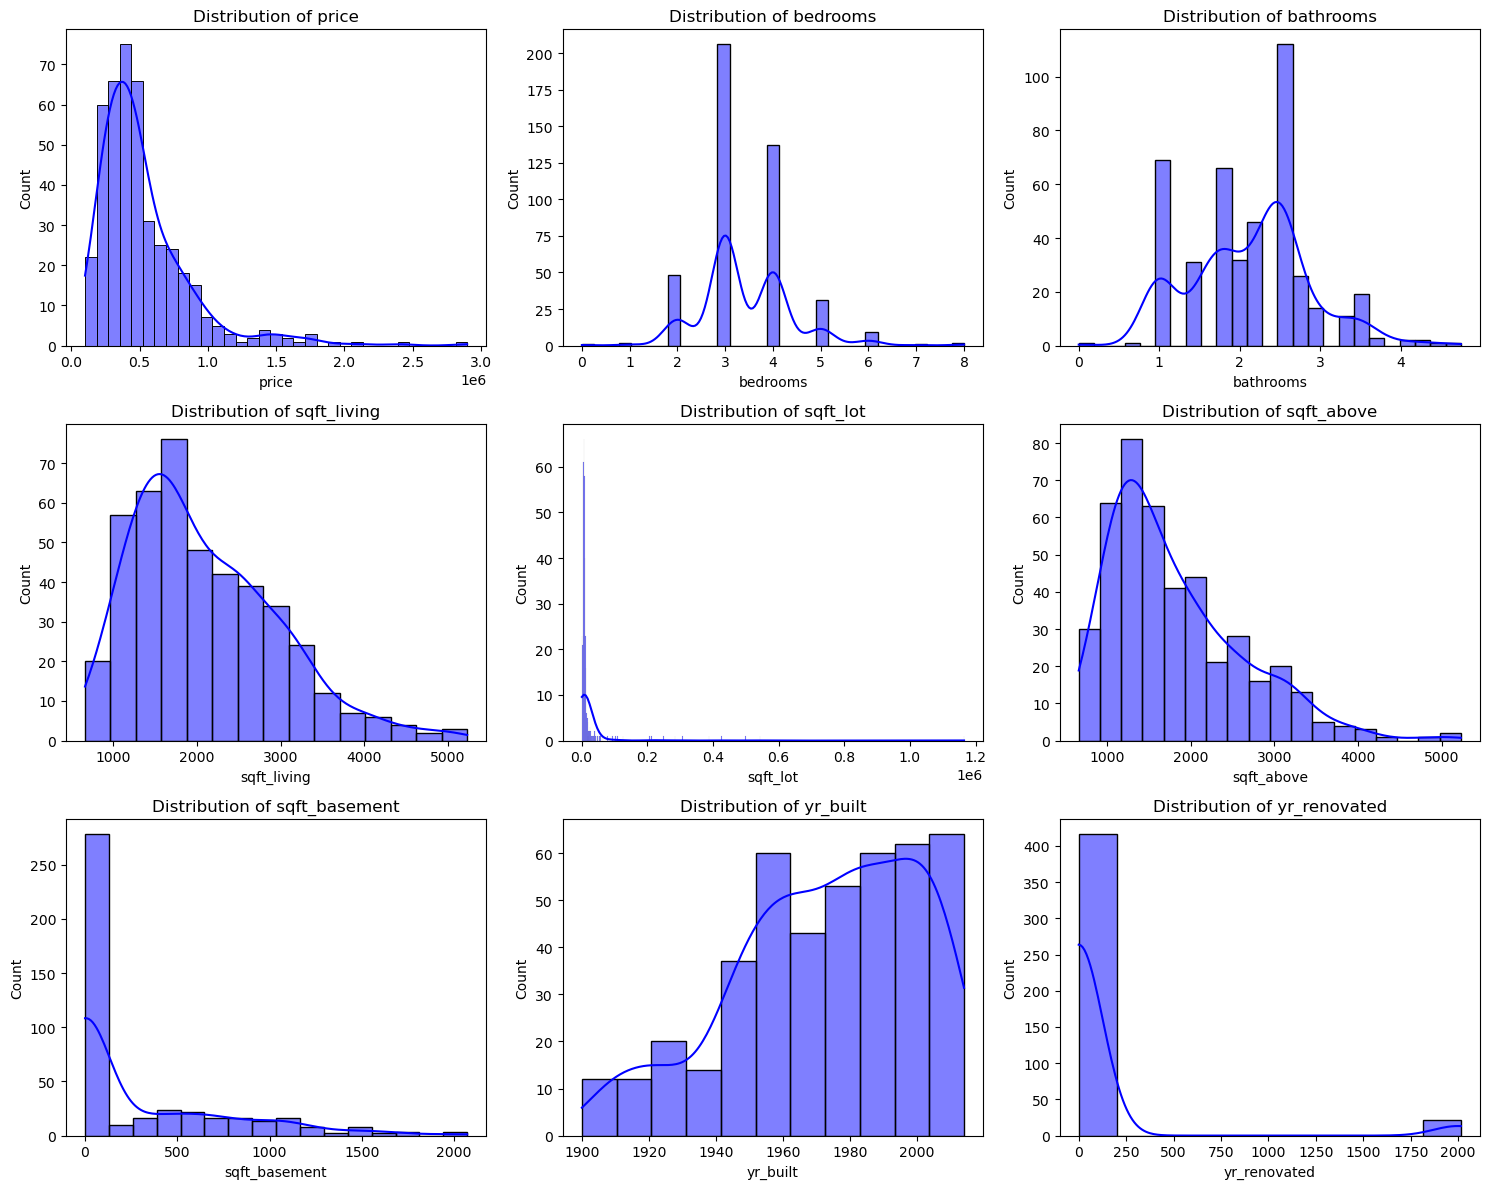

In [32]:
features = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(reldata[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

plt.show()

### Key Observations During Distribution Analysis:

#### 1. Price: Often right-skewed, indicating that most houses are in a lower price range, with a few costly properties (potential outliers).
#### 2. Square Footage (sqft_living, sqft_lot, sqft_above, sqft_basement): Larger homes are expected to be in higher demand or price brackets.
#### 3. Year Built (yr_built) and Year Renovated (yr_renovated): These might show peaks during certain periods (e.g., housing booms).
#### 4. Bedrooms and Bathrooms: Common values will likely cluster around typical home sizes (e.g., 2–4 bedrooms).

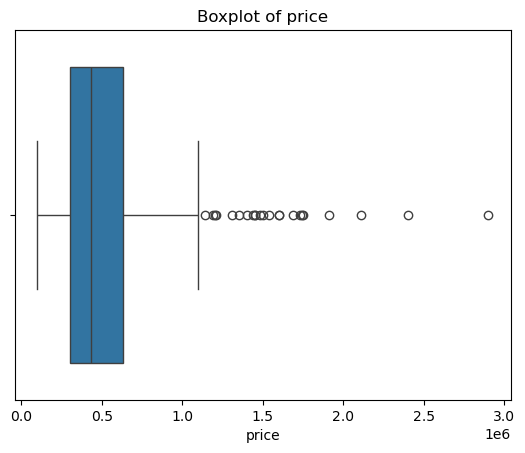

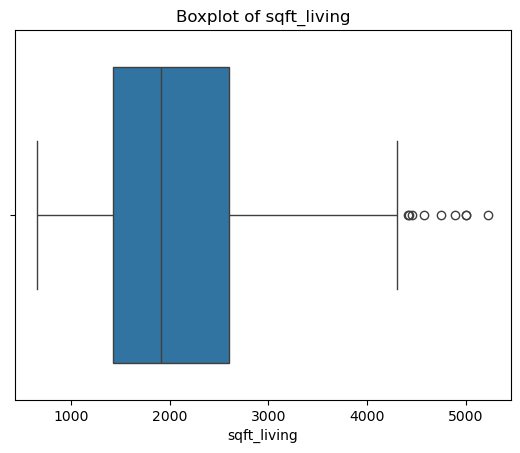

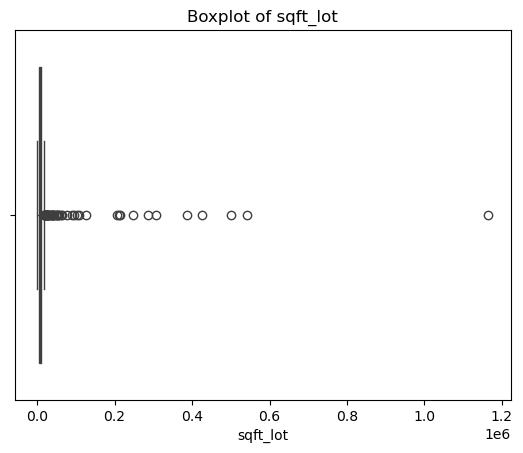

In [33]:
key_columns = ['price', 'sqft_living', 'sqft_lot'] #potetially having more outliers majorly

for col in key_columns:
    sns.boxplot(x=reldata[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

#### Checking for Outliers

In [34]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [36]:
for col in key_columns:
    outliers = detect_outliers(reldata, col)
    print(f"Number of outliers in '{col}': {len(outliers)}")

Number of outliers in 'price': 23
Number of outliers in 'sqft_living': 9
Number of outliers in 'sqft_lot': 51


In [37]:
# Function to remove outliers using the IQR method
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove outliers for selected columns
columns_to_clean = ['price', 'sqft_living', 'sqft_lot']
for col in columns_to_clean:
    data = remove_outliers(reldata, col)

print("Outliers removed. Updated dataset shape:", data.shape)

Outliers removed. Updated dataset shape: (386, 11)


In [38]:
reldata.shape

(437, 11)

##### 'data' contains the data after removal of outliers.

In [39]:
data.shape

(386, 11)

In [40]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated
count,3.860000e+02,3.860000e+02,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000
mean,4.911920e+09,5.058369e+05,3.404145,2.095855,2020.645078,7448.795337,1734.595855,286.049223,1972.564767,88.119171
std,2.816067e+09,3.323090e+05,0.965581,0.729843,825.724473,3416.195089,738.878847,452.757497,28.158774,411.086310
min,1.170001e+08,1.000000e+05,0.000000,0.000000,660.000000,895.000000,660.000000,0.000000,1900.000000,0.000000
25%,2.473300e+09,2.941200e+05,3.000000,1.750000,1400.000000,4970.000000,1200.000000,0.000000,1954.000000,0.000000
50%,4.233350e+09,4.199000e+05,3.000000,2.250000,1820.000000,7270.500000,1520.000000,0.000000,1977.000000,0.000000
75%,7.641678e+09,6.050000e+05,4.000000,2.500000,2537.500000,9462.000000,2110.000000,500.000000,1998.000000,0.000000
max,9.834201e+09,2.900000e+06,8.000000,4.500000,5000.000000,18700.000000,5000.000000,2070.000000,2014.000000,2014.000000


In [41]:
reldata.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.370000e+02,4.370000e+02,437.000000,437.000000,437.000000,4.370000e+02,437.000000,437.000000,437.000000,437.000000
mean,4.695092e+09,5.233471e+05,3.423341,2.132723,2092.622426,2.097368e+04,1806.501144,286.121281,1972.883295,95.979405
std,2.834411e+09,3.439340e+05,0.951438,0.740849,873.110453,7.642924e+04,800.475953,453.491679,27.777006,427.688605
min,4.610035e+07,1.000000e+05,0.000000,0.000000,660.000000,8.950000e+02,660.000000,0.000000,1900.000000,0.000000
25%,2.220069e+09,3.050000e+05,3.000000,1.750000,1430.000000,5.300000e+03,1210.000000,0.000000,1955.000000,0.000000
50%,4.038701e+09,4.350000e+05,3.000000,2.250000,1910.000000,7.710000e+03,1590.000000,0.000000,1977.000000,0.000000
75%,7.518503e+09,6.300000e+05,4.000000,2.500000,2605.000000,1.073200e+04,2210.000000,515.000000,1996.000000,0.000000
max,9.834201e+09,2.900000e+06,8.000000,4.750000,5230.000000,1.164794e+06,5230.000000,2070.000000,2014.000000,2014.000000


##### Boxplots after removal of outliers

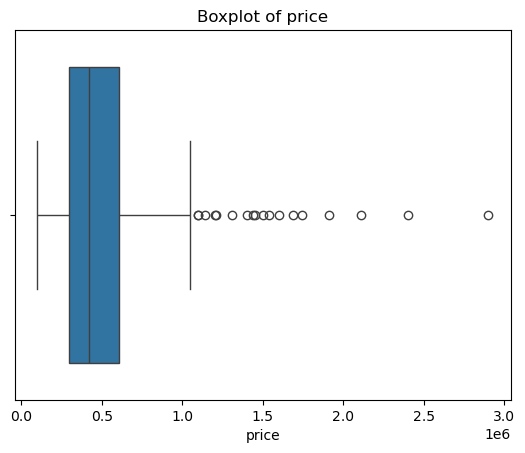

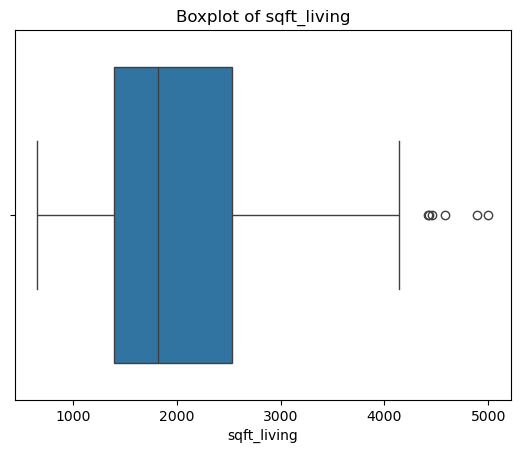

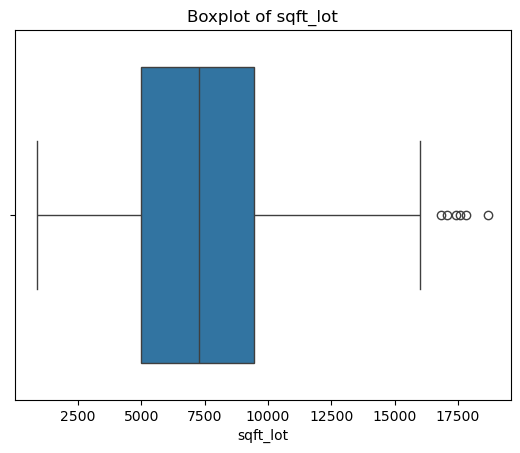

In [42]:
key_columns = ['price', 'sqft_living', 'sqft_lot']

for col in key_columns:
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

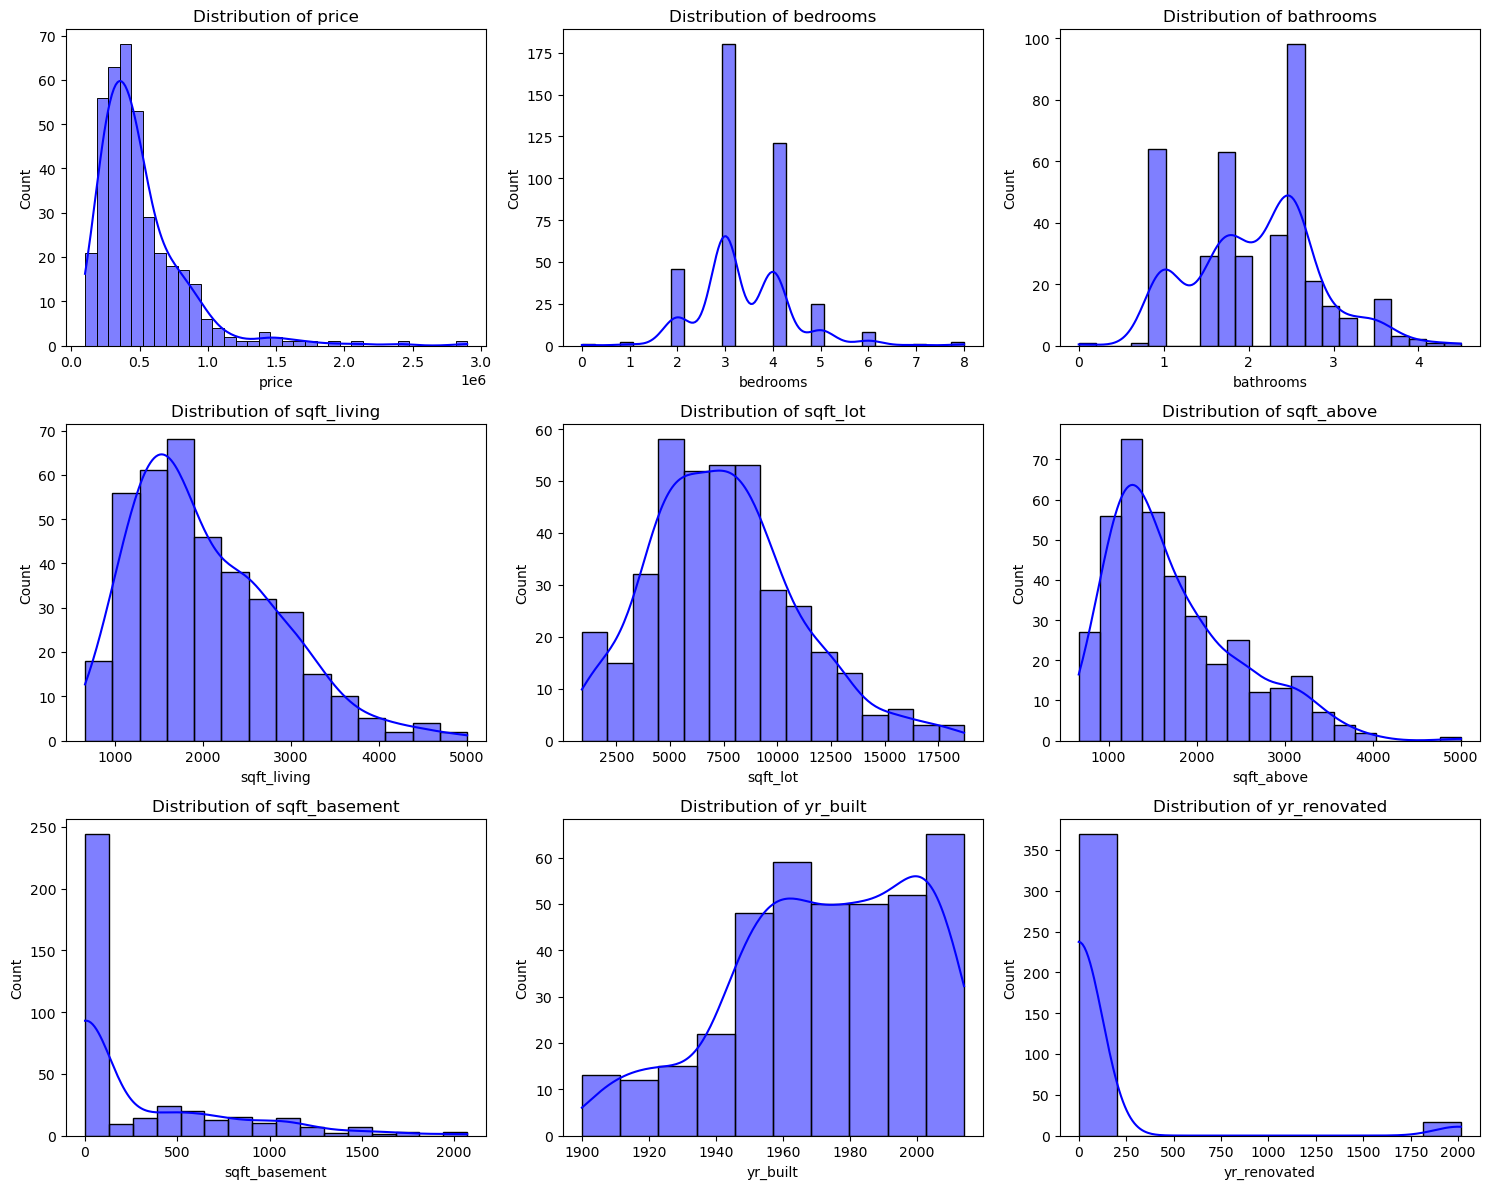

In [44]:
features = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

plt.show()

#### After removing outliers, no significant change was observed in key statistical measures, or in the visual distribution of the data (e.g. boxplots). Hence, their removal may not be strictly necessary and the original dataset (including outliers) was retained for the final analysis. 

## Scatter plots to analyze relationships with price

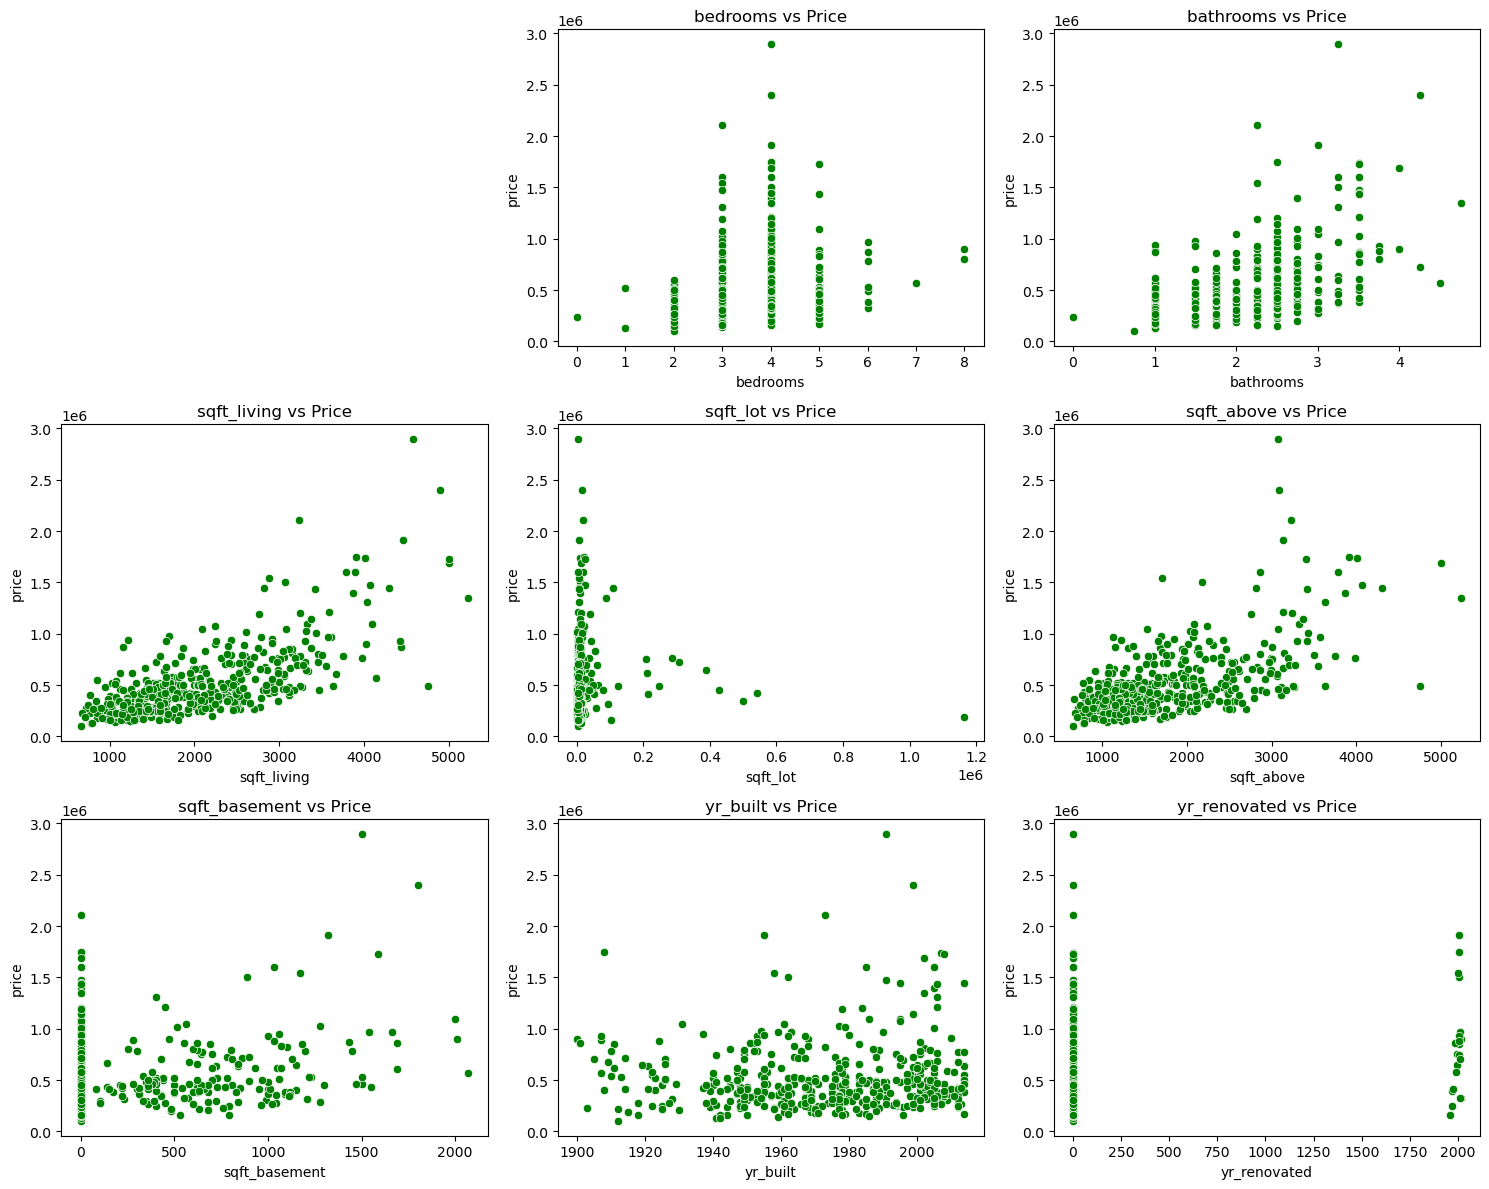

In [43]:
plt.figure(figsize=(15, 12))
for i, feature in enumerate(features, 1):
    if feature != 'price':  # Exclude the price column from being plotted against itself
        plt.subplot(3, 3, i)
        sns.scatterplot(data=reldata, x=feature, y='price', color='green')
        plt.title(f'{feature} vs Price')
        plt.tight_layout()

plt.show()

## Insights:
### 1. Price vs Sqft: sqft_living and sqft_above are likely to show a positive correlation with price, but sqft_lot might not always have a direct relationship.
### 2. Age vs Price: Newer homes or homes with significant renovations are typically priced higher.
### 3. Bedrooms and Bathrooms: The number of bedrooms and bathrooms will have a certain effect on the price, but this may depend on the total square footage.
### 4. Renovation Impact: Renovated homes may have a higher price, especially if the renovation was recent or extensive.

## Correlation between property age and price

#### Calculating the age of the property

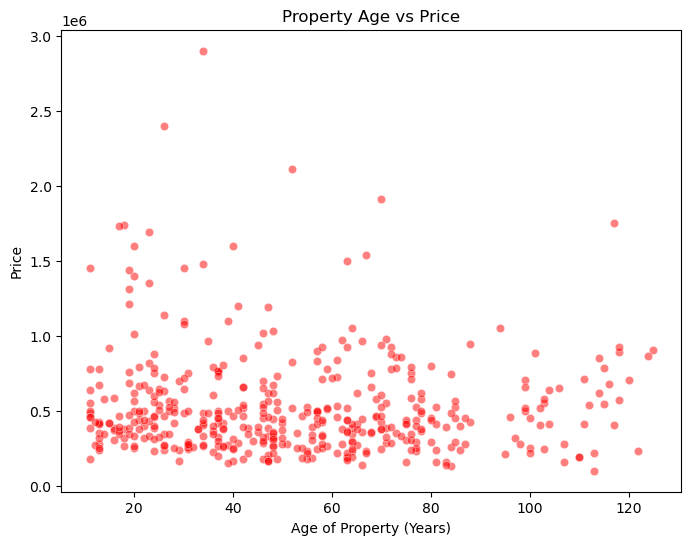

In [55]:
reldata = reldata.copy()  # Ensure it's a separate DataFrame

# Calculate property age (assuming the current year is 2025)
reldata.loc[:, 'age'] = 2025 - reldata['yr_built']

# Scatter plot of property age vs price
plt.figure(figsize=(8, 6))
sns.scatterplot(data=reldata, x='age', y='price', color='red', alpha=0.5)
plt.title('Property Age vs Price')
plt.xlabel('Age of Property (Years)')
plt.ylabel('Price')
plt.show()

In [56]:
correlation_age_price = reldata[['age', 'price']].corr()
print(correlation_age_price)

            age     price
age    1.000000 -0.066081
price -0.066081  1.000000


### Weak Negative Correlation-->
#### The correlation of -0.066 suggests that as the property age increases, the price slightly decreases, but this relationship is very weak. In other words, property age doesn't have a significant effect on the price in this dataset.

## Price vs. Square Footage

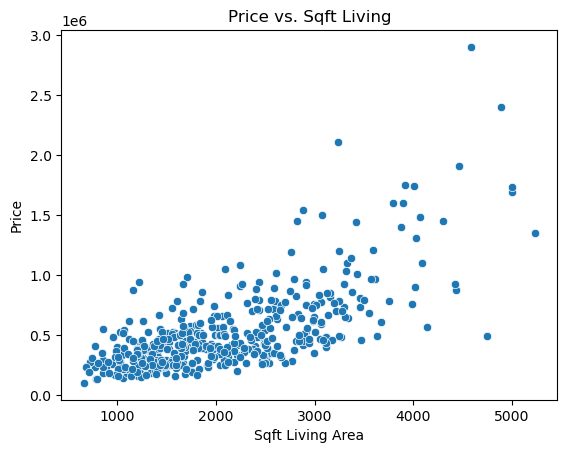

In [57]:
sns.scatterplot(x='sqft_living', y='price', data=reldata)
plt.title("Price vs. Sqft Living")
plt.xlabel("Sqft Living Area")
plt.ylabel("Price")
plt.show()

## Price vs. Bedrooms

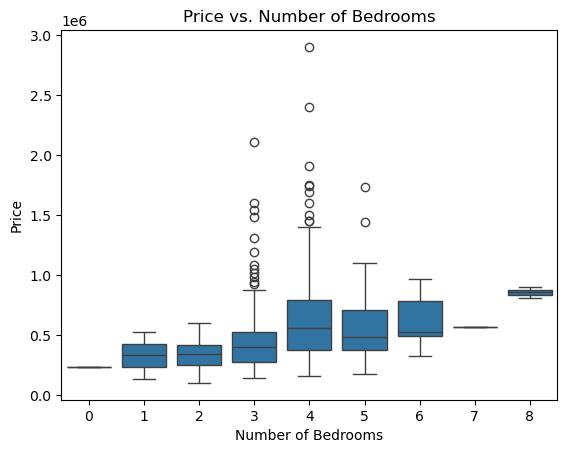

In [58]:
sns.boxplot(x='bedrooms', y='price', data=reldata)
plt.title("Price vs. Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.show()

### Interpretation:

#### 1. Price vs. Sqft Living : A clear upward trend indicates that larger houses typically cost more.
#### 2. Price vs. Bedrooms : Boxplots show the median price for houses with different numbers of bedrooms. Too many bedrooms might not always mean higher prices (e.g., very large houses might not be desirable).

## Average House Price Per Year

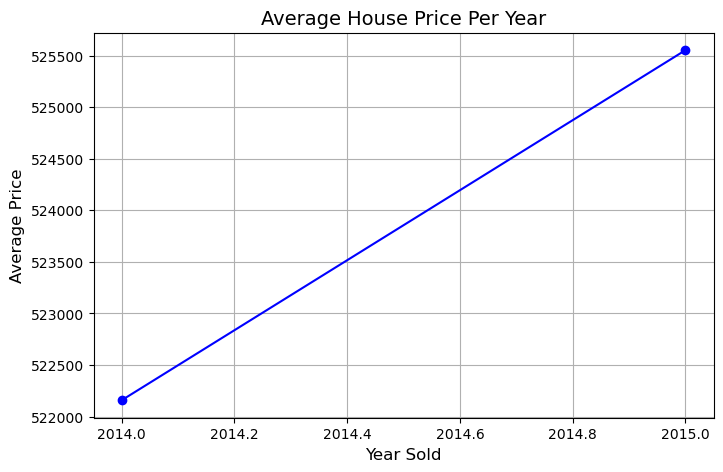

In [59]:
reldata = reldata.copy()
reldata.loc[:, 'date'] = pd.to_datetime(reldata['date'])

# Extract the year from the 'date' column
reldata.loc[:, 'year_sold'] = reldata['date'].dt.year

# Average price per year
avg_price_per_year = reldata.groupby('year_sold')['price'].mean()

# Plot the trend
plt.figure(figsize=(8, 5))
avg_price_per_year.plot(kind='line', marker='o', color='b', linestyle='-')
plt.title("Average House Price Per Year", fontsize=14)
plt.xlabel("Year Sold", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.grid(True)
plt.show()

#### If prices are increasing over the years, it might suggest a growing real estate market. If prices drop in specific years, look for external factors like economic downturns.

## Adding a column for whether the house was renovated

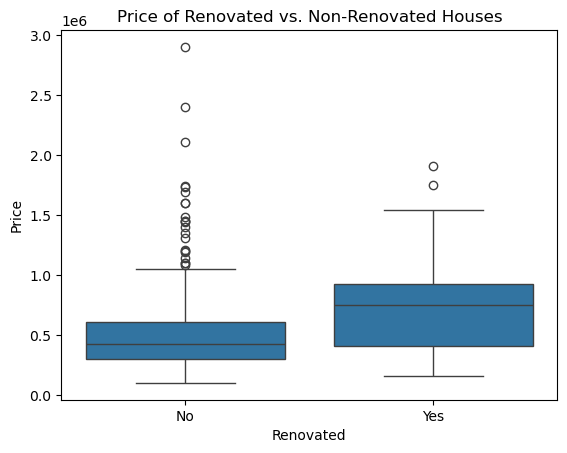

In [60]:
reldata = reldata.copy()  # Ensure it's a new DataFrame
reldata.loc[:, 'renovated'] = reldata['yr_renovated'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Boxplot of price for renovated vs non-renovated houses
sns.boxplot(x='renovated', y='price', data=reldata)
plt.title("Price of Renovated vs. Non-Renovated Houses")
plt.xlabel("Renovated")
plt.ylabel("Price")
plt.show()

#### Renovated houses typically have higher prices than non-renovated ones. If the median price of renovated houses is significantly higher, this confirms the impact of renovations.

In [61]:
reldata.shape #as 3 more new columns got added uptil here.

(437, 14)